# Upgrade Augmentation + Training Balance Notebook

This notebook upgrades the previous minority-balancing workflow with two important improvements:

1. **Better controlled augmentation**
   - variable noise per feature
   - wider but bounded perturbations
   - optional mix between interpolation and direct noisy copies

2. **Training balance support**
   - optional downsampling of very large classes
   - export of a more balanced training dataset
   - export of class weights
   - export of row weights for `WeightedRandomSampler`

This is designed for your CICIoT2023 workflow and is more training-friendly than augmentation-only.


In [1]:
from pathlib import Path
import json
import gc
import random
import warnings
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [2]:
# ============================================================
# CONFIG
# ============================================================
DATASET_PATH = Path(r"E:\dataset\processed\merged_full\dataset_34classes_clean.csv")
OUTPUT_DIR = Path(r"E:\dataset\processed_merged_full\minority_balancing_v3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_COL = "label"
DROP_DUPLICATES = True
NROWS = None

# Balancing strategy:
# "cap_all"      -> every class goes to TARGET_COUNT
# "hybrid"       -> minority classes augmented to TARGET_COUNT,
#                   majority classes downsampled to MAJORITY_CAP
# "augment_only" -> minority augmented only
BALANCE_MODE = "hybrid"

TARGET_COUNT = 300_000
MAJORITY_CAP = 300_000

# Augmentation controls
CONT_NOISE_MIN = 0.05
CONT_NOISE_MAX = 0.15
INT_NOISE_MIN = 0.02
INT_NOISE_MAX = 0.08

INTERPOLATION_PROB = 0.70
CLAMP_LOW_QUANTILE = "q01"
CLAMP_HIGH_QUANTILE = "q99"

PRESERVE_NEAR_CONSTANT = True
NEAR_CONSTANT_THRESHOLD = 0.995

EXPORT_TRAINING_ARTIFACTS = True

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15


In [3]:
print("Dataset:", DATASET_PATH)
print("Output dir:", OUTPUT_DIR)

assert DATASET_PATH.exists(), f"Dataset not found: {DATASET_PATH}"

df = pd.read_csv(DATASET_PATH, nrows=NROWS)
print("Original shape:", df.shape)

if DROP_DUPLICATES:
    dup_count = int(df.duplicated().sum())
    print("Duplicate rows:", dup_count)
    if dup_count > 0:
        df = df.drop_duplicates().reset_index(drop=True)
        print("Shape after drop_duplicates:", df.shape)

assert LABEL_COL in df.columns, f"Missing label column: {LABEL_COL}"

display(df.head())
print(df.info())


Dataset: E:\dataset\processed\merged_full\dataset_34classes_clean.csv
Output dir: E:\dataset\processed_merged_full\minority_balancing_v3
Original shape: (21005617, 34)
Duplicate rows: 303622
Shape after drop_duplicates: (20701995, 34)


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,ack_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IGMP,Tot sum,Min,Max,AVG,Std,IAT,Number,Variance,label,label_id_34
0,19.92,6.0,63.36,25893.96300,0.0,0.0,0.0,0.99,0.99,0.0,99.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.99,0.00,0.0,0.01,0.00,0.0,6421.0,60.0,481.0,64.21,42.10000,0.000039,100.0,1772.41,DDOS-PSHACK_FLOOD,8
1,0.00,47.0,64.00,3703.84130,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.01,0.0,57320.0,98.0,578.0,573.20,48.00000,0.000271,100.0,2304.00,MIRAI-GREIP_FLOOD,23
2,7.92,17.0,65.91,19673.09600,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.99,0.0,0.00,0.01,0.0,6010.0,60.0,70.0,60.10,1.00000,0.000057,100.0,1.00,DOS-UDP_FLOOD,21
3,20.40,6.0,110.50,261.66483,0.1,0.0,0.3,0.20,0.40,0.0,4.0,0.0,0.50,0.0,0.0,0.0,0.0,0.0,0.70,0.20,0.0,0.10,0.00,0.0,2223.0,54.0,1500.0,222.30,451.59668,0.004766,10.0,203939.56,DNS_SPOOFING,17
4,0.32,1.0,63.96,28944.20000,0.0,0.0,0.0,0.00,0.01,0.0,1.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.01,0.00,0.0,0.00,0.99,0.0,6006.0,60.0,66.0,60.06,0.60000,0.000035,100.0,0.36,DDOS-ICMP_FLOOD,6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20701995 entries, 0 to 20701994
Data columns (total 34 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Header_Length    float64
 1   Protocol Type    float64
 2   Time_To_Live     float64
 3   Rate             float64
 4   fin_flag_number  float64
 5   syn_flag_number  float64
 6   rst_flag_number  float64
 7   psh_flag_number  float64
 8   ack_flag_number  float64
 9   ece_flag_number  float64
 10  ack_count        float64
 11  HTTP             float64
 12  HTTPS            float64
 13  DNS              float64
 14  Telnet           float64
 15  SMTP             float64
 16  SSH              float64
 17  IRC              float64
 18  TCP              float64
 19  UDP              float64
 20  DHCP             float64
 21  ARP              float64
 22  ICMP             float64
 23  IGMP             float64
 24  Tot sum          float64
 25  Min              float64
 26  Max              float64
 27  AVG       

Header_Length    0
Min              0
UDP              0
DHCP             0
ARP              0
ICMP             0
IGMP             0
Tot sum          0
Max              0
Protocol Type    0
AVG              0
Std              0
IAT              0
Number           0
Variance         0
label            0
TCP              0
IRC              0
SSH              0
SMTP             0
dtype: int64

Numeric feature count: 32
First features: ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'ack_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP']


,label,count
0,DDOS-ICMP_FLOOD,1893583
1,DDOS-UDP_FLOOD,1876996
2,DDOS-SYN_FLOOD,1749348
3,DOS-UDP_FLOOD,1720950
4,DDOS-PSHACK_FLOOD,1637353
5,DDOS-TCP_FLOOD,1538829
6,DDOS-RSTFINFLOOD,1248655
7,DDOS-SYNONYMOUSIP_FLOOD,1166360
8,DOS-SYN_FLOOD,1133753
9,DOS-TCP_FLOOD,1112260


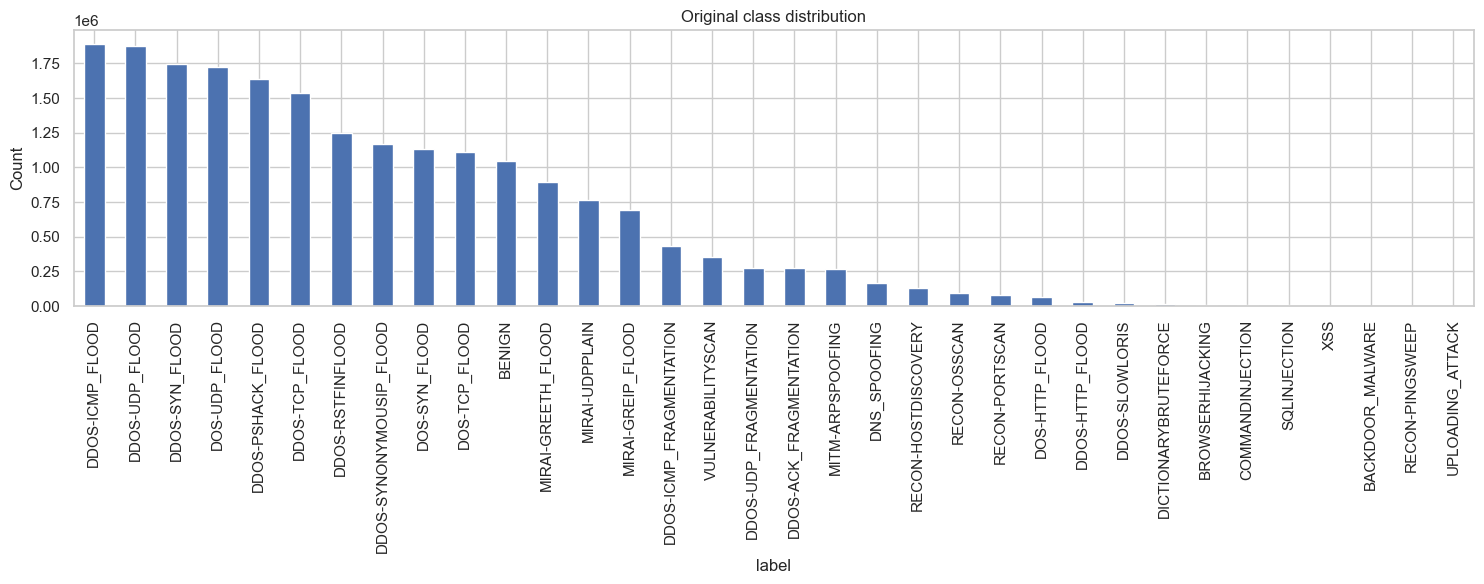

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
display(missing.head(20))

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in ["label_id_34"]]
print("Numeric feature count:", len(feature_cols))
print("First features:", feature_cols[:20])

class_counts = df[LABEL_COL].value_counts().sort_values(ascending=False)
class_dist_df = class_counts.rename_axis("label").reset_index(name="count")
display(class_dist_df)

plt.figure(figsize=(15, 6))
class_counts.plot(kind="bar")
plt.title("Original class distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [5]:
balance_plan = class_dist_df.copy()
balance_plan["target_count"] = TARGET_COUNT
balance_plan["to_generate"] = 0
balance_plan["to_drop"] = 0

for idx, row in balance_plan.iterrows():
    count = int(row["count"])
    target = int(row["target_count"])

    if BALANCE_MODE == "cap_all":
        if count < target:
            balance_plan.loc[idx, "to_generate"] = target - count
        elif count > target:
            balance_plan.loc[idx, "to_drop"] = count - target

    elif BALANCE_MODE == "hybrid":
        if count < target:
            balance_plan.loc[idx, "to_generate"] = target - count
        elif count > MAJORITY_CAP:
            balance_plan.loc[idx, "to_drop"] = count - MAJORITY_CAP

    elif BALANCE_MODE == "augment_only":
        if count < target:
            balance_plan.loc[idx, "to_generate"] = target - count
    else:
        raise ValueError(f"Unknown BALANCE_MODE: {BALANCE_MODE}")

balance_plan["final_count"] = balance_plan["count"] + balance_plan["to_generate"] - balance_plan["to_drop"]

display(balance_plan)
print("Rows before:", int(balance_plan["count"].sum()))
print("Rows after :", int(balance_plan["final_count"].sum()))

minority_labels = balance_plan.loc[balance_plan["to_generate"] > 0, "label"].tolist()
majority_drop_labels = balance_plan.loc[balance_plan["to_drop"] > 0, "label"].tolist()

print("Minority classes to augment:", minority_labels)
print("Majority classes to downsample:", majority_drop_labels)


,label,count,target_count,to_generate,to_drop,final_count
0,DDOS-ICMP_FLOOD,1893583,300000,0,1593583,300000
1,DDOS-UDP_FLOOD,1876996,300000,0,1576996,300000
2,DDOS-SYN_FLOOD,1749348,300000,0,1449348,300000
3,DOS-UDP_FLOOD,1720950,300000,0,1420950,300000
4,DDOS-PSHACK_FLOOD,1637353,300000,0,1337353,300000
5,DDOS-TCP_FLOOD,1538829,300000,0,1238829,300000
6,DDOS-RSTFINFLOOD,1248655,300000,0,948655,300000
7,DDOS-SYNONYMOUSIP_FLOOD,1166360,300000,0,866360,300000
8,DOS-SYN_FLOOD,1133753,300000,0,833753,300000
9,DOS-TCP_FLOOD,1112260,300000,0,812260,300000


Rows before: 20701995
Rows after : 10200000
Minority classes to augment: ['DDOS-UDP_FRAGMENTATION', 'DDOS-ACK_FRAGMENTATION', 'MITM-ARPSPOOFING', 'DNS_SPOOFING', 'RECON-HOSTDISCOVERY', 'RECON-OSSCAN', 'RECON-PORTSCAN', 'DOS-HTTP_FLOOD', 'DDOS-HTTP_FLOOD', 'DDOS-SLOWLORIS', 'DICTIONARYBRUTEFORCE', 'BROWSERHIJACKING', 'COMMANDINJECTION', 'SQLINJECTION', 'XSS', 'BACKDOOR_MALWARE', 'RECON-PINGSWEEP', 'UPLOADING_ATTACK']
Majority classes to downsample: ['DDOS-ICMP_FLOOD', 'DDOS-UDP_FLOOD', 'DDOS-SYN_FLOOD', 'DOS-UDP_FLOOD', 'DDOS-PSHACK_FLOOD', 'DDOS-TCP_FLOOD', 'DDOS-RSTFINFLOOD', 'DDOS-SYNONYMOUSIP_FLOOD', 'DOS-SYN_FLOOD', 'DOS-TCP_FLOOD', 'BENIGN', 'MIRAI-GREETH_FLOOD', 'MIRAI-UDPPLAIN', 'MIRAI-GREIP_FLOOD', 'DDOS-ICMP_FRAGMENTATION', 'VULNERABILITYSCAN']


In [6]:
def describe_class(df_class, feature_cols):
    rows = []
    for col in feature_cols:
        s = df_class[col].astype(float)
        vc = s.value_counts(dropna=False, normalize=True)
        top_freq = float(vc.iloc[0]) if len(vc) else np.nan
        rows.append({
            "feature": col,
            "min": float(s.min()),
            "q01": float(s.quantile(0.01)),
            "q05": float(s.quantile(0.05)),
            "median": float(s.median()),
            "mean": float(s.mean()),
            "q95": float(s.quantile(0.95)),
            "q99": float(s.quantile(0.99)),
            "max": float(s.max()),
            "std": float(s.std(ddof=0)),
            "nonzero_ratio": float((s != 0).mean()),
            "top_value_ratio": top_freq,
            "is_constant_in_class": bool(s.nunique(dropna=False) <= 1),
            "is_near_constant_in_class": bool(top_freq >= NEAR_CONSTANT_THRESHOLD),
        })
    return pd.DataFrame(rows)

class_behavior_dir = OUTPUT_DIR / "class_behavior"
class_behavior_dir.mkdir(parents=True, exist_ok=True)

class_feature_bounds = {}
summary_rows = []

for label in class_counts.index.tolist():
    df_class = df[df[LABEL_COL] == label].copy()
    desc = describe_class(df_class, feature_cols)
    desc.to_csv(class_behavior_dir / f"{label}_feature_profile.csv", index=False)

    class_feature_bounds[label] = {
        row["feature"]: {
            "min": row["min"],
            "q01": row["q01"],
            "q05": row["q05"],
            "median": row["median"],
            "mean": row["mean"],
            "q95": row["q95"],
            "q99": row["q99"],
            "max": row["max"],
            "std": row["std"],
        }
        for _, row in desc.iterrows()
    }

    summary_rows.append({
        "label": label,
        "count": int(len(df_class)),
        "n_constant_features": int(desc["is_constant_in_class"].sum()),
        "n_near_constant_features": int(desc["is_near_constant_in_class"].sum()),
        "mean_std_across_features": float(desc["std"].mean()),
    })

class_behavior_summary = pd.DataFrame(summary_rows).sort_values("count")
display(class_behavior_summary)
class_behavior_summary.to_csv(OUTPUT_DIR / "class_behavior_summary.csv", index=False)

with open(OUTPUT_DIR / "class_feature_bounds.json", "w", encoding="utf-8") as f:
    json.dump(class_feature_bounds, f, indent=2)


,label,count,n_constant_features,n_near_constant_features,mean_std_across_features
33,UPLOADING_ATTACK,1196,4,6,27477.593127
32,RECON-PINGSWEEP,2161,5,5,25908.716936
31,BACKDOOR_MALWARE,3075,4,5,52013.247748
30,XSS,3705,4,5,33463.843353
29,SQLINJECTION,5022,4,6,13622.308027
28,COMMANDINJECTION,5150,4,5,27523.264165
27,BROWSERHIJACKING,5560,5,7,27468.748361
26,DICTIONARYBRUTEFORCE,12520,3,4,23407.357398
25,DDOS-SLOWLORIS,22400,3,5,20085.631426
24,DDOS-HTTP_FLOOD,27597,3,6,7431.871357


In [7]:
binary_like_cols = []
integer_like_cols = []
continuous_cols = []

for col in feature_cols:
    s = df[col].dropna().astype(float)
    uniq = np.sort(s.unique())

    if len(uniq) <= 8 and s.between(0, 1).mean() > 0.99:
        binary_like_cols.append(col)
    elif np.allclose(s, np.round(s), atol=1e-6):
        integer_like_cols.append(col)
    else:
        continuous_cols.append(col)

print("Binary-like cols :", len(binary_like_cols), binary_like_cols)
print("Integer-like cols:", len(integer_like_cols), integer_like_cols)
print("Continuous cols  :", len(continuous_cols))


Binary-like cols : 0 []
Integer-like cols: 6 ['Protocol Type', 'ack_count', 'Tot sum', 'Min', 'Max', 'Number']
Continuous cols  : 26


In [8]:
def generate_synthetic_for_class_v3(
    class_df,
    n_generate,
    feature_cols,
    bounds,
    binary_cols,
    integer_cols,
    continuous_cols,
    label_col="label",
    preserve_near_constant=True,
    near_constant_threshold=0.995,
    interpolation_prob=0.70,
    cont_noise_min=0.05,
    cont_noise_max=0.15,
    int_noise_min=0.02,
    int_noise_max=0.08,
    clamp_low_q="q01",
    clamp_high_q="q99",
    seed=42,
):
    rng = np.random.default_rng(seed)

    if n_generate <= 0:
        return class_df.iloc[0:0].copy()

    class_df = class_df.reset_index(drop=True).copy()
    X = class_df[feature_cols].copy()

    near_constant_info = {}
    for col in feature_cols:
        vc = X[col].value_counts(normalize=True, dropna=False)
        if len(vc) > 0:
            near_constant_info[col] = (float(vc.index[0]), float(vc.iloc[0]))
        else:
            near_constant_info[col] = (0.0, 1.0)

    idx_a = rng.integers(0, len(X), size=n_generate)
    idx_b = rng.integers(0, len(X), size=n_generate)
    Xa = X.iloc[idx_a].to_numpy(dtype=np.float32)
    Xb = X.iloc[idx_b].to_numpy(dtype=np.float32)

    use_interp = rng.random(n_generate) < interpolation_prob
    lam = rng.uniform(0.15, 0.85, size=n_generate).astype(np.float32)

    Xs = np.empty_like(Xa, dtype=np.float32)
    Xs[use_interp] = lam[use_interp, None] * Xa[use_interp] + (1.0 - lam[use_interp, None]) * Xb[use_interp]
    Xs[~use_interp] = Xa[~use_interp]

    for j, col in enumerate(feature_cols):
        col_bounds = bounds[col]
        col_std = max(float(col_bounds["std"]), 1e-8)

        if col in binary_cols:
            probs = rng.random(n_generate)
            Xs[:, j] = np.where(probs < 0.5, Xa[:, j], Xb[:, j])
            Xs[:, j] = np.clip(Xs[:, j], 0.0, 1.0)

        elif col in integer_cols:
            noise_scale = rng.uniform(int_noise_min, int_noise_max)
            noise = rng.normal(0.0, noise_scale * col_std, size=n_generate)
            Xs[:, j] = np.round(Xs[:, j] + noise)

        else:
            noise_scale = rng.uniform(cont_noise_min, cont_noise_max)
            noise = rng.normal(0.0, noise_scale * col_std, size=n_generate)
            Xs[:, j] = Xs[:, j] + noise

        top_val, top_freq = near_constant_info[col]
        if preserve_near_constant and top_freq >= near_constant_threshold:
            mask = rng.random(n_generate) < top_freq
            Xs[mask, j] = top_val

        low = float(col_bounds[clamp_low_q])
        high = float(col_bounds[clamp_high_q])
        if not np.isfinite(low) or not np.isfinite(high) or low >= high:
            low = float(col_bounds["min"])
            high = float(col_bounds["max"])

        Xs[:, j] = np.clip(Xs[:, j], low, high)

    synth = pd.DataFrame(Xs, columns=feature_cols)
    synth[label_col] = class_df[label_col].iloc[0]
    return synth


In [9]:
synthetic_parts = []
augmentation_report = []

for _, row in balance_plan.iterrows():
    label = row["label"]
    current_count = int(row["count"])
    to_generate = int(row["to_generate"])
    final_target = int(row["final_count"])

    if to_generate <= 0:
        augmentation_report.append({
            "label": label,
            "original_count": current_count,
            "generated_count": 0,
            "downsampled_count": int(row["to_drop"]),
            "final_target": final_target,
        })
        continue

    print(f"Generating for {label} | current={current_count:,} | generate={to_generate:,} | final={final_target:,}")

    class_df = df[df[LABEL_COL] == label].copy()
    synth_df = generate_synthetic_for_class_v3(
        class_df=class_df,
        n_generate=to_generate,
        feature_cols=feature_cols,
        bounds=class_feature_bounds[label],
        binary_cols=binary_like_cols,
        integer_cols=integer_like_cols,
        continuous_cols=continuous_cols,
        label_col=LABEL_COL,
        preserve_near_constant=PRESERVE_NEAR_CONSTANT,
        near_constant_threshold=NEAR_CONSTANT_THRESHOLD,
        interpolation_prob=INTERPOLATION_PROB,
        cont_noise_min=CONT_NOISE_MIN,
        cont_noise_max=CONT_NOISE_MAX,
        int_noise_min=INT_NOISE_MIN,
        int_noise_max=INT_NOISE_MAX,
        clamp_low_q=CLAMP_LOW_QUANTILE,
        clamp_high_q=CLAMP_HIGH_QUANTILE,
        seed=SEED,
    )

    synthetic_parts.append(synth_df)

    augmentation_report.append({
        "label": label,
        "original_count": current_count,
        "generated_count": int(len(synth_df)),
        "downsampled_count": int(row["to_drop"]),
        "final_target": final_target,
    })

    del class_df, synth_df
    gc.collect()

augmentation_report_df = pd.DataFrame(augmentation_report).sort_values("original_count")
display(augmentation_report_df)
augmentation_report_df.to_csv(OUTPUT_DIR / "augmentation_report_v3.csv", index=False)


Generating for DDOS-UDP_FRAGMENTATION | current=273,415 | generate=26,585 | final=300,000
Generating for DDOS-ACK_FRAGMENTATION | current=271,537 | generate=28,463 | final=300,000
Generating for MITM-ARPSPOOFING | current=268,962 | generate=31,038 | final=300,000
Generating for DNS_SPOOFING | current=166,925 | generate=133,075 | final=300,000
Generating for RECON-HOSTDISCOVERY | current=127,863 | generate=172,137 | final=300,000
Generating for RECON-OSSCAN | current=92,323 | generate=207,677 | final=300,000
Generating for RECON-PORTSCAN | current=76,789 | generate=223,211 | final=300,000
Generating for DOS-HTTP_FLOOD | current=68,445 | generate=231,555 | final=300,000
Generating for DDOS-HTTP_FLOOD | current=27,597 | generate=272,403 | final=300,000
Generating for DDOS-SLOWLORIS | current=22,400 | generate=277,600 | final=300,000
Generating for DICTIONARYBRUTEFORCE | current=12,520 | generate=287,480 | final=300,000
Generating for BROWSERHIJACKING | current=5,560 | generate=294,440 | f

,label,original_count,generated_count,downsampled_count,final_target
33,UPLOADING_ATTACK,1196,298804,0,300000
32,RECON-PINGSWEEP,2161,297839,0,300000
31,BACKDOOR_MALWARE,3075,296925,0,300000
30,XSS,3705,296295,0,300000
29,SQLINJECTION,5022,294978,0,300000
28,COMMANDINJECTION,5150,294850,0,300000
27,BROWSERHIJACKING,5560,294440,0,300000
26,DICTIONARYBRUTEFORCE,12520,287480,0,300000
25,DDOS-SLOWLORIS,22400,277600,0,300000
24,DDOS-HTTP_FLOOD,27597,272403,0,300000


In [10]:
synthetic_df = pd.concat(synthetic_parts, ignore_index=True) if synthetic_parts else df.iloc[0:0].copy()
print("Synthetic shape:", synthetic_df.shape)

balanced_parts = []
for _, row in balance_plan.iterrows():
    label = row["label"]
    class_df = df[df[LABEL_COL] == label].copy()
    to_drop = int(row["to_drop"])

    if to_drop > 0:
        keep_n = max(int(len(class_df) - to_drop), 1)
        class_df = class_df.sample(n=keep_n, random_state=SEED)

    balanced_parts.append(class_df)

base_balanced_df = pd.concat(balanced_parts, ignore_index=True)
final_df = pd.concat([base_balanced_df, synthetic_df], ignore_index=True)

print("Base balanced shape:", base_balanced_df.shape)
print("Final shape:", final_df.shape)

before_counts = df[LABEL_COL].value_counts().sort_index()
after_counts = final_df[LABEL_COL].value_counts().sort_index()

before_after = pd.DataFrame({"before": before_counts, "after": after_counts}).fillna(0).astype(int).sort_values("after", ascending=False)
display(before_after)
before_after.to_csv(OUTPUT_DIR / "class_distribution_before_after_v3.csv")


Synthetic shape: (3965355, 33)
Base balanced shape: (6234645, 34)
Final shape: (10200000, 34)


,before,after
label,,
BACKDOOR_MALWARE,3075,300000
MITM-ARPSPOOFING,268962,300000
DOS-SYN_FLOOD,1133753,300000
DOS-TCP_FLOOD,1112260,300000
DOS-UDP_FLOOD,1720950,300000
MIRAI-GREETH_FLOOD,895892,300000
MIRAI-GREIP_FLOOD,693641,300000
MIRAI-UDPPLAIN,764963,300000
RECON-HOSTDISCOVERY,127863,300000


In [11]:
plausibility_rows = []

for label in minority_labels:
    real_df = df[df[LABEL_COL] == label]
    synth_df_label = synthetic_df[synthetic_df[LABEL_COL] == label]
    if len(synth_df_label) == 0:
        continue

    for col in feature_cols:
        plausibility_rows.append({
            "label": label,
            "feature": col,
            "real_mean": float(real_df[col].mean()),
            "synth_mean": float(synth_df_label[col].mean()),
            "abs_mean_diff": float(abs(real_df[col].mean() - synth_df_label[col].mean())),
            "real_std": float(real_df[col].std(ddof=0)),
            "synth_std": float(synth_df_label[col].std(ddof=0)),
            "real_min": float(real_df[col].min()),
            "synth_min": float(synth_df_label[col].min()),
            "real_max": float(real_df[col].max()),
            "synth_max": float(synth_df_label[col].max()),
        })

plausibility_df = pd.DataFrame(plausibility_rows)
display(plausibility_df.head(20))
plausibility_df.to_csv(OUTPUT_DIR / "plausibility_stats_v3.csv", index=False)

plausibility_summary = (
    plausibility_df.groupby("label")[["abs_mean_diff", "real_std", "synth_std"]]
    .mean()
    .reset_index()
    .sort_values("abs_mean_diff")
)
display(plausibility_summary)
plausibility_summary.to_csv(OUTPUT_DIR / "plausibility_summary_v3.csv", index=False)


,label,feature,real_mean,synth_mean,abs_mean_diff,real_std,synth_std,real_min,synth_min,real_max,synth_max
0,DDOS-UDP_FRAGMENTATION,Header_Length,4.638671,4.616778e+00,0.021893,2.375504,1.731512e+00,0.00000,3.680000,5.212000e+01,17.799999
1,DDOS-UDP_FRAGMENTATION,Protocol Type,16.869144,1.686564e+01,0.003505,1.219156,1.036045e+00,0.00000,6.000000,1.700000e+01,17.000000
2,DDOS-UDP_FRAGMENTATION,Time_To_Live,65.850872,6.573107e+01,0.119801,7.408759,4.968630e+00,10.92000,59.369999,2.550000e+02,99.709999
3,DDOS-UDP_FRAGMENTATION,Rate,2205.825864,2.270618e+03,64.791811,16307.656161,1.945067e+03,0.00161,146.447968,3.145728e+06,7655.158203
4,DDOS-UDP_FRAGMENTATION,fin_flag_number,0.001297,1.315729e-03,0.000019,0.005354,3.406461e-03,0.00000,0.000000,5.000000e-01,0.020000
5,DDOS-UDP_FRAGMENTATION,syn_flag_number,0.005195,5.227760e-03,0.000033,0.012733,9.244853e-03,0.00000,0.000000,5.000000e-01,0.060000
6,DDOS-UDP_FRAGMENTATION,rst_flag_number,0.000958,1.090298e-03,0.000133,0.006360,2.980991e-03,0.00000,0.000000,4.600000e-01,0.020000
7,DDOS-UDP_FRAGMENTATION,psh_flag_number,0.007134,7.052056e-03,0.000082,0.028410,1.773555e-02,0.00000,0.000000,8.200000e-01,0.140000
8,DDOS-UDP_FRAGMENTATION,ack_flag_number,0.021840,2.207937e-02,0.000239,0.081421,5.676169e-02,0.00000,0.000000,1.000000e+00,0.460000
9,DDOS-UDP_FRAGMENTATION,ece_flag_number,0.000134,1.963690e-04,0.000063,0.001521,9.415195e-04,0.00000,0.000000,2.500000e-01,0.010000


,label,abs_mean_diff,real_std,synth_std
9,DOS-HTTP_FLOOD,22.008160,15067.304428,12030.994597
4,DDOS-HTTP_FLOOD,29.128409,7431.871357,5576.681066
13,RECON-PINGSWEEP,78.158532,25908.716936,16750.201291
6,DDOS-UDP_FRAGMENTATION,82.753564,3835.870467,983.506875
8,DNS_SPOOFING,93.295943,7791.583193,6300.131926
12,RECON-OSSCAN,102.068873,30460.715382,18791.585489
7,DICTIONARYBRUTEFORCE,154.900807,23407.357398,13922.758098
3,DDOS-ACK_FRAGMENTATION,176.863857,5642.337694,1238.982584
5,DDOS-SLOWLORIS,197.679882,20085.631426,15504.757381
15,SQLINJECTION,204.325238,13622.308027,6920.130732


In [12]:
if EXPORT_TRAINING_ARTIFACTS:
    train_df, temp_df = train_test_split(
        final_df,
        test_size=(1.0 - TRAIN_RATIO),
        stratify=final_df[LABEL_COL],
        random_state=SEED
    )

    val_ratio_adjusted = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=(1.0 - val_ratio_adjusted),
        stratify=temp_df[LABEL_COL],
        random_state=SEED
    )

    print("Train:", train_df.shape)
    print("Val  :", val_df.shape)
    print("Test :", test_df.shape)

    train_dir = OUTPUT_DIR / "training_ready"
    train_dir.mkdir(parents=True, exist_ok=True)

    train_df.to_csv(train_dir / "train.csv", index=False)
    val_df.to_csv(train_dir / "val.csv", index=False)
    test_df.to_csv(train_dir / "test.csv", index=False)

    label_to_id = {label: idx for idx, label in enumerate(sorted(final_df[LABEL_COL].unique()))}
    with open(train_dir / "label_mapping_34.pkl", "wb") as f:
        pickle.dump(label_to_id, f)

    y_train = train_df[LABEL_COL].map(label_to_id).to_numpy()
    classes = np.unique(y_train)
    class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}

    with open(train_dir / "class_weights_34.pkl", "wb") as f:
        pickle.dump(class_weight_dict, f)

    row_weights = np.array([class_weight_dict[int(c)] for c in y_train], dtype=np.float32)
    np.save(train_dir / "weighted_sampler_row_weights.npy", row_weights)

    pd.DataFrame({
        "label": [k for k, _ in sorted(label_to_id.items(), key=lambda kv: kv[1])],
        "label_id": [v for _, v in sorted(label_to_id.items(), key=lambda kv: kv[1])]
    }).to_csv(train_dir / "label_mapping_34.csv", index=False)

    pd.DataFrame({
        "class_id": list(class_weight_dict.keys()),
        "weight": list(class_weight_dict.values()),
    }).to_csv(train_dir / "class_weights_34.csv", index=False)

    print("Training artifacts saved to:", train_dir)


Train: (7139999, 34)
Val  : (1530000, 34)
Test : (1530001, 34)
Training artifacts saved to: E:\dataset\processed_merged_full\minority_balancing_v3\training_ready


In [13]:
final_csv_path = OUTPUT_DIR / "dataset_34classes_balanced_v3.csv"
synthetic_csv_path = OUTPUT_DIR / "synthetic_only_v3.csv"
base_balanced_path = OUTPUT_DIR / "base_balanced_without_synthetic_v3.csv"

final_df.to_csv(final_csv_path, index=False)
synthetic_df.to_csv(synthetic_csv_path, index=False)
base_balanced_df.to_csv(base_balanced_path, index=False)

summary = {
    "dataset_path": str(DATASET_PATH),
    "output_dir": str(OUTPUT_DIR),
    "n_rows_original": int(len(df)),
    "n_rows_synthetic": int(len(synthetic_df)),
    "n_rows_base_balanced": int(len(base_balanced_df)),
    "n_rows_final": int(len(final_df)),
    "n_features": int(len(feature_cols)),
    "balance_mode": BALANCE_MODE,
    "target_count": int(TARGET_COUNT),
    "majority_cap": int(MAJORITY_CAP),
    "minority_class_count": int(len(minority_labels)),
    "majority_drop_class_count": int(len(majority_drop_labels)),
    "export_training_artifacts": bool(EXPORT_TRAINING_ARTIFACTS),
}

with open(OUTPUT_DIR / "balancing_summary_v3.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved:")
print("-", final_csv_path)
print("-", synthetic_csv_path)
print("-", base_balanced_path)
print("-", OUTPUT_DIR / "augmentation_report_v3.csv")
print("-", OUTPUT_DIR / "class_distribution_before_after_v3.csv")
print("-", OUTPUT_DIR / "plausibility_stats_v3.csv")
print("-", OUTPUT_DIR / "plausibility_summary_v3.csv")
print("-", OUTPUT_DIR / "balancing_summary_v3.json")


Saved:
- E:\dataset\processed_merged_full\minority_balancing_v3\dataset_34classes_balanced_v3.csv
- E:\dataset\processed_merged_full\minority_balancing_v3\synthetic_only_v3.csv
- E:\dataset\processed_merged_full\minority_balancing_v3\base_balanced_without_synthetic_v3.csv
- E:\dataset\processed_merged_full\minority_balancing_v3\augmentation_report_v3.csv
- E:\dataset\processed_merged_full\minority_balancing_v3\class_distribution_before_after_v3.csv
- E:\dataset\processed_merged_full\minority_balancing_v3\plausibility_stats_v3.csv
- E:\dataset\processed_merged_full\minority_balancing_v3\plausibility_summary_v3.csv
- E:\dataset\processed_merged_full\minority_balancing_v3\balancing_summary_v3.json


## Recommended first run

Use these defaults first:
- `BALANCE_MODE = "hybrid"`
- `TARGET_COUNT = 300_000`
- `MAJORITY_CAP = 300_000`

That gives you:
- augmentation for minority classes
- downsampling for overly dominant classes
- a much more training-friendly class distribution
